# CNN Lab - CIFAR10 Dataset
Sinh viên thực hiện CNN thuần (không dùng pretrained model).

Yêu cầu:
- Phân tích dữ liệu
- Cân bằng dữ liệu
- Huấn luyện CNN
- Đạt accuracy > 90% và giảm overfitting

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

## Data Augmentation và Load Dataset

In [9]:
import torchvision
import torchvision.transforms as transforms

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform_train)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

## Visualize dữ liệu

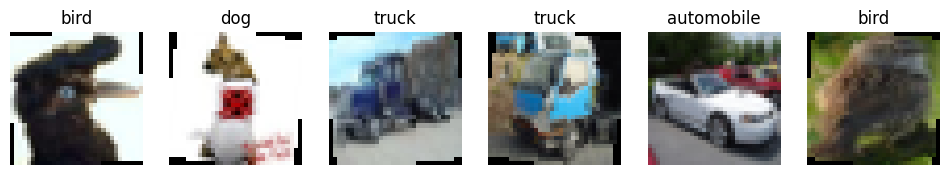

In [3]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1,6, figsize=(12,3))

for i in range(6):
    img = images[i] / 2 + 0.5
    axes[i].imshow(np.transpose(img.numpy(), (1,2,0)))
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.show()

## Phân tích và kiểm tra cân bằng dữ liệu

In [ ]:
labels_list = [label for _, label in train_dataset]
counter = Counter(labels_list)

for i in counter:
    print(classes[i], counter[i])

frog 5000
truck 5000
deer 5000
automobile 5000
bird 5000
horse 5000
ship 5000
cat 5000
dog 5000
airplane 5000


## Xây dựng CNN Model

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(128*4*4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 128*4*4)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

## Khởi tạo model và optimizer

In [11]:
import torch.optim as optim

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Training Model

In [15]:
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 260.0786
Epoch 2, Loss: 253.5833
Epoch 3, Loss: 248.9406
Epoch 4, Loss: 244.7341
Epoch 5, Loss: 243.0458
Epoch 6, Loss: 239.8103
Epoch 7, Loss: 237.0778
Epoch 8, Loss: 234.4034
Epoch 9, Loss: 230.6700
Epoch 10, Loss: 227.3884
Epoch 11, Loss: 223.0348
Epoch 12, Loss: 222.1386
Epoch 13, Loss: 217.9240
Epoch 14, Loss: 215.5326
Epoch 15, Loss: 213.8550
Epoch 16, Loss: 212.6405
Epoch 17, Loss: 211.3225
Epoch 18, Loss: 210.2157
Epoch 19, Loss: 205.6952
Epoch 20, Loss: 207.1569
Epoch 21, Loss: 203.0267
Epoch 22, Loss: 199.2539
Epoch 23, Loss: 199.9953
Epoch 24, Loss: 195.5007
Epoch 25, Loss: 194.5525
Epoch 26, Loss: 193.3666
Epoch 27, Loss: 191.4006
Epoch 28, Loss: 191.1186
Epoch 29, Loss: 187.8343
Epoch 30, Loss: 187.2702


## Đánh giá Accuracy

In [16]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 83.86%
